In [5]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

np.random.seed(31)
customer_orders_weighted = pd.DataFrame({
    "CustomerID": np.arange(1, 1001),
    "OrderDate": pd.date_range(start="2023-01-01", periods=1000, freq="D"),
    "Repurchase": np.random.choice([0, 1], size=1000, p=[0.7, 0.3])
})
customer_orders_weighted["OrderAmount"] = np.where(
    customer_orders_weighted["Repurchase"] == 1,
    np.random.randint(500, 1000, size=1000),
    np.random.randint(10, 500, size=1000)
)


customer_orders_random = pd.DataFrame({
    "CustomerID": np.arange(1, 1001),
    "OrderDate": pd.date_range(start="2023-01-01", periods=1000, freq="D"),
    "Repurchase": np.random.choice([0, 1], size=1000, p=[0.7, 0.3]),
    "OrderAmount": np.random.randint(10, 1000, size=1000)
})

In [7]:
customer_orders_weighted

,CustomerID,OrderDate,Repurchase,OrderAmount
0,1,2023-01-01,0,177
1,2,2023-01-02,1,975
2,3,2023-01-03,1,761
3,4,2023-01-04,1,749
4,5,2023-01-05,0,445
...,...,...,...,...
995,996,2025-09-22,1,808
996,997,2025-09-23,1,596
997,998,2025-09-24,0,196
998,999,2025-09-25,0,29


In [9]:
customer_orders_random

,CustomerID,OrderDate,Repurchase,OrderAmount
0,1,2023-01-01,0,240
1,2,2023-01-02,1,869
2,3,2023-01-03,0,511
3,4,2023-01-04,1,511
4,5,2023-01-05,0,825
...,...,...,...,...
995,996,2025-09-22,0,259
996,997,2025-09-23,1,141
997,998,2025-09-24,0,100
998,999,2025-09-25,1,183


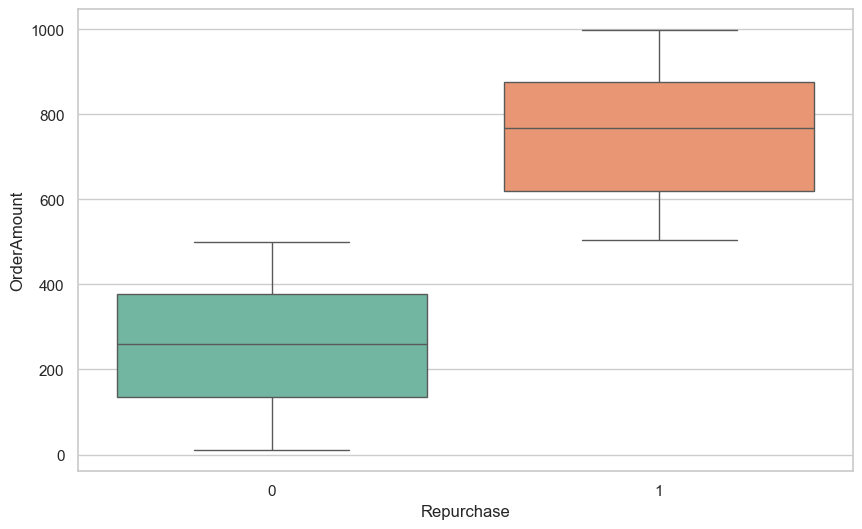

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')

plt.figure(figsize=(10,6))
sns.boxplot(x='Repurchase', y='OrderAmount', data=customer_orders_weighted, hue='Repurchase', palette='Set2', legend=False)
plt.show()

In [ ]:
sns.boxplot(x='Repurchase', y='OrderAmount', data=customer_orders_weighted, hue='Repurchase', palette='Set2', legend=False)
sns.boxplot(x='Repurchase', y='OrderAmount', data=customer_orders_weighted)


In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [19]:
X = customer_orders_random[['OrderAmount']]
y = customer_orders_random[['Repurchase']]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=111)

In [21]:
dt = DecisionTreeClassifier(random_state=111)
dt.fit(X_train, y_train)


y_pred = dt.predict(X_test)

In [23]:
dt

DecisionTreeClassifier(random_state=111)

In [25]:
y_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0])

In [27]:
acc =accuracy_score(y_test, y_pred)
print(acc)

0.585


In [29]:
X = customer_orders_weighted[['OrderAmount']]
y = customer_orders_weighted[['Repurchase']]



X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=111)


dt = DecisionTreeClassifier(random_state=111)
dt.fit(X_train, y_train)


y_pred = dt.predict(X_test)


acc =accuracy_score(y_test, y_pred)
print(acc)

1.0


In [31]:
missing_indices=np.random.choice(customer_orders_random.index, size= int(0.1 * len(customer_orders_random)), replace=False)
customer_orders_random.loc[missing_indices, 'OrderAmount'] = np.nan 

In [33]:
customer_orders_random.isna().sum()

CustomerID       0
OrderDate        0
Repurchase       0
OrderAmount    100
dtype: int64

In [35]:
X= customer_orders_random['OrderAmount'].values.reshape(-1,1)
y= customer_orders_random['Repurchase']

In [37]:
X_no_na =X[~np.isnan(X[:,0])] 
y_no_na =y[~np.isnan(X[:,0])] 


X_train, X_test, y_train, y_test = train_test_split(X_no_na,y_no_na, test_size=0.2, random_state=111)

dt = DecisionTreeClassifier(random_state=111)
dt.fit(X_train, y_train)


y_pred = dt.predict(X_test)


acc =accuracy_score(y_test, y_pred)
print(acc)

0.6111111111111112


In [39]:
np.isnan(X[:,0])

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False,  True, False, False, False, False,  True,
       False, False, False, False, False,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [41]:
missing_indices

array([ 97, 665, 834, 170, 158, 599, 341, 528, 320, 155, 905, 135, 966,
        62, 203, 563,  57, 659, 462, 968, 142, 691, 669,  68, 114, 587,
       463,  29, 293, 741, 557, 453,  84, 515, 577, 859,  70, 601, 466,
       524, 489, 807, 828, 684, 934, 538,  28, 609, 715, 938, 854, 512,
       467, 184,  55, 408, 397, 932, 560, 516, 631, 775, 600,  37, 655,
       977, 327, 623, 633, 393, 355, 607,  99,  35, 230, 602, 744, 164,
       460, 172, 555, 824, 746, 392, 247, 745, 611, 657, 626, 751, 654,
       267, 724, 428, 646, 719, 200, 375, 785, 178], dtype=int64)